# Volatility Paper Code

Import required packages

In [22]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List

Plot Figure for Paper

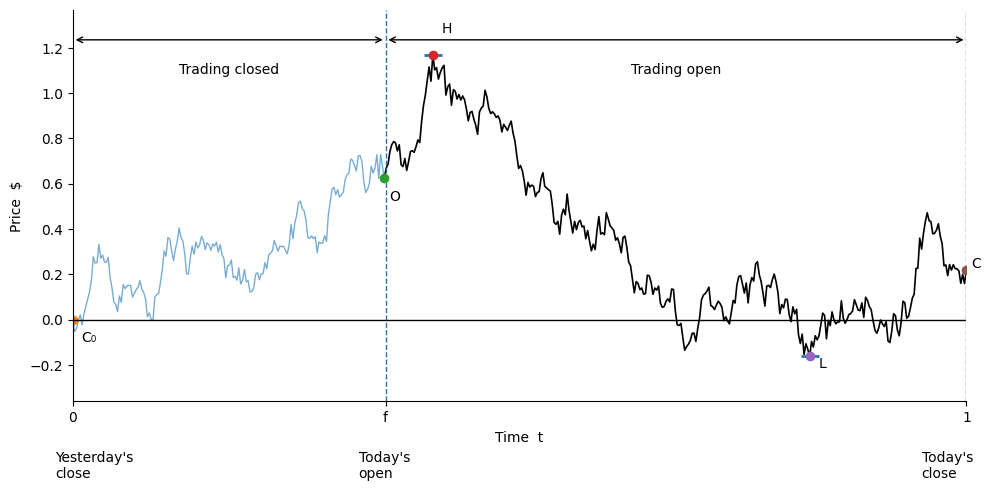

In [26]:

# parameters
seed = 100
N = 480                # points over the day
f = 0.35               # open fraction in [0,1]
rng = np.random.default_rng(seed)

# simulate a simple Brownian-like path
t = np.linspace(0, 1, N)
dt = 1 / (N - 1)
x = np.concatenate([[0.0], np.cumsum(np.sqrt(dt) * rng.standard_normal(N - 1))])

# pick open, high, low, close
i_open = int(f * (N - 1))
seg = x[i_open:]
iH = i_open + np.argmax(seg)
iL = i_open + np.argmin(seg)

C0 = x[0]
O  = x[i_open]
H  = x[iH]
L  = x[iL]
C  = x[-1]

fig, ax = plt.subplots(figsize=(10, 5))

# closed vs open periods
ax.plot(t[:i_open+1], x[:i_open+1], lw=1, alpha=0.6)
ax.plot(t[i_open:], x[i_open:], lw=1.2, color="black")

# vertical dashed lines for open and close
ax.axvline(f, ls="--", lw=1)
ax.axvline(1, ls="--", lw=1)

# small horizontal ticks at H and L
tick_w = 0.02
ax.hlines(H, t[iH]-tick_w/2, t[iH]+tick_w/2, lw=2)
ax.hlines(L, t[iL]-tick_w/2, t[iL]+tick_w/2, lw=2)

# point markers
ax.plot(t[0], C0, "o")
ax.plot(t[i_open], O, "o")
ax.plot(t[iH], H, "o")
ax.plot(t[iL], L, "o")
ax.plot(t[-1], C, "o")

# labels for points
ax.annotate("C₀", (t[0], C0), xytext=(t[0]+0.01, C0-0.1))
ax.annotate("O",  (t[i_open], O), xytext=(t[i_open]+0.005, O-0.1))
ax.annotate("H",  (t[iH], H), xytext=(t[iH]+0.01, H+0.1))
ax.annotate("L",  (t[iL], L), xytext=(t[iL]+0.01, L-0.05))
ax.annotate("C",  (t[-1], C), xytext=(t[-1]+0.005, C+0.01))

# x-axis ticks and labels
ax.set_xticks([0, f, 1])
ax.set_xticklabels(["0", "f", "1"])
ax.axhline(0, lw=1, color="black")

# bottom captions
ax.annotate("Yesterday's\nclose", (0, 0), xytext=(-0.02, -0.7))
ax.annotate("Today's\nopen", (f, 0), xytext=(f-0.03, -0.7))
ax.annotate("Today's\nclose", (1, 0), xytext=(1-0.05, -0.7))

# top timeline arrows
ax.annotate("", xy=(0, ax.get_ylim()[1]), xytext=(f, ax.get_ylim()[1]),
            arrowprops=dict(arrowstyle="<->"))
ax.annotate("", xy=(f, ax.get_ylim()[1]), xytext=(1, ax.get_ylim()[1]),
            arrowprops=dict(arrowstyle="<->"))
ax.text(0.5*f, ax.get_ylim()[1]-0.1, "Trading closed", ha="center", va="top")
ax.text((1+f)/2, ax.get_ylim()[1]-0.1, "Trading open", ha="center", va="top")

# axis labels
ax.set_ylabel("Price  $")
ax.set_xlabel("Time  t")

# cosmetics
ax.set_xlim(0, 1)
ax.margins(y=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("simple_OHLC_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

# plt.savefig("gk_style_chart.png", dpi=300)Utility Functions

In [6]:
def _safe_log(x: np.ndarray) -> np.ndarray:
    """Numerically safe natural log."""
    return np.log(np.clip(x, 1e-300, None))

def _require_columns(df: pd.DataFrame, cols: List[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

@dataclass
class EstimatorResults:
    """Container for per‑day estimates and an aggregate scalar."""
    per_day: pd.Series
    aggregate: float

Functions for Classical Estimators

In [7]:
def cc_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Close‑to‑close (CC): per day r_t^2 with r_t = ln(C_t/C_{t-1}).
    Aggregate = mean of daily r^2.
    """
    _require_columns(df, ["Close"])
    close = df["Close"].to_numpy(float)
    r = _safe_log(close[1:] / close[:-1])
    per_day = pd.Series(np.concatenate([[np.nan], r**2]), index=df.index, name="CC")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def parkinson_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Parkinson (1980): (1/(4 ln 2)) * [ln(H/L)]^2 per day; aggregate = mean.
    """
    _require_columns(df, ["High", "Low"])
    hl = _safe_log(df["High"].to_numpy(float) / df["Low"].to_numpy(float))
    per_day = pd.Series((hl**2) / (4.0 * math.log(2.0)), index=df.index, name="PK")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def garman_klass_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Garman–Klass practical (no drift):
      0.5 * [ln(H/L)]^2  - (2 ln 2 - 1) * [ln(C/O)]^2
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    h_l = _safe_log(H / L)
    c_o = _safe_log(C / O)
    per_day = pd.Series(0.5*h_l**2 - (2.0*math.log(2.0) - 1.0)*c_o**2,
                        index=df.index, name="GK")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def rogers_satchell_variance(df: pd.DataFrame) -> EstimatorResults:
    """
    Rogers–Satchell (drift‑robust) per day:
      u*(u - c) + d*(d - c) where u=ln(H/O), d=ln(L/O), c=ln(C/O).
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    u = _safe_log(H / O); d = _safe_log(L / O); c = _safe_log(C / O)
    per_day = pd.Series(u*(u - c) + d*(d - c), index=df.index, name="RS")
    return EstimatorResults(per_day=per_day, aggregate=float(np.nanmean(per_day)))

def yang_zhang_variance(df: pd.DataFrame, alpha: float = 1.34) -> EstimatorResults:
    """
    Yang–Zhang multi‑period:
      V = VO + k*VC + (1 - k)*VRS, with
      VO = sample var of o_i = ln(O_i / C_{i-1})
      VC = sample var of c_i = ln(C_i / O_i)
      VRS = mean of RS_i (per‑day RS term)
      k = (alpha - 1) / (alpha + 1 + 2/(n - 1))
    Returns per_day = RS component (for plotting) and aggregate scalar V.
    """
    _require_columns(df, ["Open", "High", "Low", "Close"])
    O, H, L, C = (df[c].to_numpy(float) for c in ["Open", "High", "Low", "Close"])
    C_prev = np.concatenate([[np.nan], C[:-1]])
    o = _safe_log(O / C_prev)  # overnight; first NaN
    c = _safe_log(C / O)
    u = _safe_log(H / O); d = _safe_log(L / O)
    rs = u*(u - c) + d*(d - c)

    mask = ~np.isnan(o); n = int(mask.sum())
    if n < 2: raise ValueError("Need ≥2 periods for YZ.")
    VO = float(np.var(o[mask], ddof=1))
    VC = float(np.var(c[mask], ddof=1))
    VRS = float(np.mean(rs[mask]))
    k = (alpha - 1.0) / (alpha + 1.0 + 2.0/(n - 1.0))
    V = VO + k*VC + (1.0 - k)*VRS

    return EstimatorResults(per_day=pd.Series(rs, index=df.index, name="YZ_component_RS"),
                            aggregate=V)


NULL Space Framework

In [8]:
def null_space_basis(K: np.ndarray, tol: float = 1e-12) -> np.ndarray:
    """
    Orthonormal basis for Null(K).  K: (#constraints × #terms).
    """
    U, S, VT = np.linalg.svd(K, full_matrices=True)
    r = (S > tol).sum()
    V = VT.T
    m = K.shape[1]
    return np.zeros((m, 0)) if r == m else V[:, r:]

def particular_solution(K: np.ndarray, target: np.ndarray) -> np.ndarray:
    """Minimum‑norm particular solution a_p to K a = target via pseudoinverse."""
    return np.linalg.pinv(K) @ target

def optimal_weights_from_nullspace(
    K: np.ndarray,
    target: np.ndarray,
    Pi: np.ndarray,
    B: Optional[np.ndarray] = None,
    a_p: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Solve:  minimize a^T Π a  s.t. K a = target
    using a = a_p + B α with B basis of Null(K).
    α* = −(B^T Π B)^{-1} B^T Π a_p,   a* = a_p + B α*
    """
    if a_p is None: a_p = particular_solution(K, target)
    if B is None:   B   = null_space_basis(K)
    if B.size == 0:
        return a_p, {"B": B, "a_p": a_p, "alpha_star": np.zeros(0)}
    BT_Pi_B = B.T @ Pi @ B
    BT_Pi_ap = B.T @ Pi @ a_p
    alpha_star = -np.linalg.solve(BT_Pi_B, BT_Pi_ap)
    a_star = a_p + B @ alpha_star
    return a_star, {"B": B, "a_p": a_p, "alpha_star": alpha_star}

Monte Carlo Simulation

In [27]:
def simulate_bm_day_extremes(n_paths: int = 100_000, n_steps: int = 1_000,
                             seed: Optional[int] = 42) -> Dict[str, np.ndarray]:
    """
    Simulate Brownian motion (µ=0, σ=1) over [0,1]; open O=0.
    Return arrays for u=H-O, d=L-O, c=C-O (O=0 baseline).
    """
    rng = np.random.default_rng(seed)
    dt = 1.0 / n_steps
    dB = rng.normal(0.0, math.sqrt(dt), size=(n_paths, n_steps))
    X = np.cumsum(dB, axis=1)
    H = X.max(axis=1)
    L = X.min(axis=1)
    C = X[:, -1]
    return {"u": H, "d": L, "c": C}

def empirical_covariance_matrix(x_terms: np.ndarray) -> np.ndarray:
    X = np.asarray(x_terms)
    Xc = X - X.mean(axis=0, keepdims=True)
    return (Xc.T @ Xc) / (X.shape[0] - 1)

def ohlc_nullspace_optimal_weights_monte_carlo(
    n_paths: int = 50_000, n_steps: int = 1_000, seed: Optional[int] = 123
) -> Dict[str, float]:
    """
    OHLC quadratic family:
      x = [u^2, d^2, c^2, u d, u c, d c]^T
    Constraint: unbiased ⇒ K a = 1 with K = [E[x_i]] (estimated here by MC).
    Π is the empirical covariance of x.

    Returns weights dict keyed by ["u2","d2","c2","u_d","u_c","d_c"].
    """
    sim = simulate_bm_day_extremes(n_paths=n_paths, n_steps=n_steps, seed=seed)
    u, d, c = sim["u"], sim["d"], sim["c"]
    X = np.column_stack([u**2, d**2, c**2, u*d, u*c, d*c])
    K = X.mean(axis=0, keepdims=True)
    target = np.array([1.0])
    Pi = empirical_covariance_matrix(X)
    a_star, _ = optimal_weights_from_nullspace(K, target, Pi)
    terms = ["u2", "d2", "c2", "u_d", "u_c", "d_c"]
    return {t: float(w) for t, w in zip(terms, a_star)}


In [28]:
simulate_bm_day_extremes()

{'u': array([0.17332315, 0.3078732 , 1.0762915 , ..., 0.51201986, 1.16433007,
        0.14081993], shape=(100000,)),
 'd': array([-1.24817266, -2.71597722, -0.28576105, ..., -0.46634444,
        -0.01246639, -2.57252966], shape=(100000,)),
 'c': array([-0.91363106, -2.57340953,  1.06572567, ..., -0.12888533,
         1.16433007, -2.33397952], shape=(100000,))}